*Sources:*
- The impact of long-range dispersal on gene surfing (Halletschek, 2020)
- Acceleration of evolutionary spread by long-range dispersal (Fisher, 2014)

Notebook for KPZ surface simulations.


This notebook modifies the effective time of the simulation. The physics this simulation has to model is long-range spreading at where all source sites try to proliferate at a constant rate. This can be accomplished in two ways:

1) One is to define a single effective time step (ETS) as $\sim L^d$ computational time steps (CTS), where for each CTS, one tries to sample from each lattice site randomly. If a source site is selected, we give it a chance to proliferate with some establishment probability. The important thing about this "sample from all method" is that the rate of proliferation attempts is constant --- the proliferation attempts per ETS scales with the number of source sites in the simulation.
2) Second is to define a single ETS as $1/\text{number of occupied sites}$ CTS, where for each CTS, one samples from the existing source sites at random. Therefore, the the number of proliferation attempts per ETS will still scale with the number of source sites in the simulation. 

In [35]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt

import numpy as np
import numba
from scipy.ndimage import binary_erosion

**Power jump sampling**. To sample from a jump $r$ from jump distribution $J(r, \mu)$ where $r_0 < r < \infty$, where normalized distribution is
$$
J(r, \mu) = \mu r_0^\mu r^{-(\mu+1)}
$$
we use inverse transform sampling. That is, we draw $F \sim \mathrm{Unif}[0,1]$ and then into the inverse CDF to get a draw $r$ from $J(r, \mu)$:
$$
r = r_0 (1-F)^{-1/\mu}
$$

## Simulation

In [48]:
def sample_power_law_jump(mu: float, rng: np.random.Generator, min_jump: float = np.sqrt(2)) -> float:
    """
    Sample jump distance xi from:
        J(xi, mu) = mu * xi^(-(mu + 1)),  xi >= min_jump
    via inverse transform sampling.

    Returns jump distasnce r in interval [min_jump, infty]
    """
    if mu <= 0:
        raise ValueError("mu must be > 0 for a normalizable jump distribution.")
    u = rng.random()
    return min_jump * (1.0 - u) ** (-1.0 / mu)

def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y) # get valid points that are positive and finite
    if np.count_nonzero(mask) < 2: # can only fit a line if there are more than 2 valid points
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1) 
    return float(slope)


@numba.njit(cache=True)
def _sw_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    l_min: int,
    l_max: int,
) -> np.ndarray:
    """Incremental sliding-window OLS kernel, compiled by Numba.

    Maintains six running sums (n, Σx, Σx², Σy, Σxy, Σy²) for the current
    window and updates them in O(1) as the window shifts one column right:

      1. Remove the exiting column (local k=0 — contributes 0 to x-weighted
         sums, so only n, Σy, Σy² change).
      2. Shift all remaining local positions k → k-1, updating Σx, Σx², Σxy
         via the recurrences:
             Σx   ← Σx  − n_remaining
             Σx²  ← Σx² − 2·Σx + n_remaining
             Σxy  ← Σxy − Σy_remaining
      3. Add the entering column at local k = l−1.

    This gives O(L + l) work per l value instead of the O(L·l) cost of
    building the full sliding-window matrix, for a ~200× reduction across
    the full l range.

    Args:
        n_col:      Per-column surface-site counts,        shape (L,).
        sum_y_col:  Per-column Σy of surface sites,        shape (L,).
        sum_y2_col: Per-column Σy² of surface sites,       shape (L,).
        l_min:      Smallest window width.
        l_max:      Largest window width.

    Returns:
        Array of shape (l_max − l_min + 1,) with w(l) for each l.
    """
    L = n_col.shape[0]
    n_ls = l_max - l_min + 1
    widths = np.empty(n_ls)

    for li in range(n_ls):
        l   = l_min + li
        lm1 = float(l - 1)

        # ── Initialise stats for the first window [0, l) ────────────────
        n_w = 0.0; sx = 0.0; sx2 = 0.0
        sy  = 0.0; sxy = 0.0; sy2 = 0.0
        for k in range(l):
            fk   = float(k)
            n_k  = n_col[k]
            sy_k = sum_y_col[k]
            n_w  += n_k
            sx   += fk * n_k
            sx2  += fk * fk * n_k
            sy   += sy_k
            sxy  += fk * sy_k
            sy2  += sum_y2_col[k]

        mse_total = 0.0
        valid     = 0

        for x in range(L):
            # ── OLS MSE for this window ───────────────────────────────────
            if n_w >= 2.0:
                SS_xx = sx2 - sx  * sx  / n_w
                SS_xy = sxy - sx  * sy  / n_w
                SS_yy = sy2 - sy  * sy  / n_w
                if SS_xx > 0.0:
                    mse_total += np.sqrt((SS_yy - SS_xy * SS_xy / SS_xx) / n_w)
                else:
                    mse_total += np.sqrt(SS_yy / n_w)  # degenerate: all points same column
                valid += 1

            # ── Slide right ───────────────────────────────────────────────
            x_add = (x + l) % L

            # 1. Remove column x (local k=0; contributes 0 to x-weighted sums)
            n_rem   = n_w  - n_col[x]
            sy_rem  = sy   - sum_y_col[x]
            sy2_rem = sy2  - sum_y2_col[x]

            # 2. Shift remaining k → k-1
            sx_s  = sx  - n_rem
            sx2_s = sx2 - 2.0 * sx + n_rem
            sxy_s = sxy - sy_rem

            # 3. Add entering column at local k = l-1
            n_a  = n_col[x_add]
            sy_a = sum_y_col[x_add]
            n_w  = n_rem   + n_a
            sx   = sx_s    + lm1 * n_a
            sx2  = sx2_s   + lm1 * lm1 * n_a
            sy   = sy_rem  + sy_a
            sxy  = sxy_s   + lm1 * sy_a
            sy2  = sy2_rem + sum_y2_col[x_add]

        widths[li] = mse_total / valid if valid > 0 else np.nan

    return widths


class StochasticGrowthStripGeometry:
    """Stochastic growth on L by L SQUARE lattice with 2 populations.
    Population A_1 -> 1
    Population A_2 -> 2
    Unoccupied -> 0
    
    Periodic boundary conditions in x (cylinder geometry)."""

    def __init__(self, L: int, mu: float, seed: int = 42):
        if L < 2:
            raise ValueError("L must be at least 2")
        self.L = int(L) 
        self.mu = float(mu) # jump kernel dist.
        self.rng = np.random.default_rng(seed) # random number generator for sims
        self.grid = np.zeros((self.L, self.L), dtype=np.int8)

        # initialize source strip
        self._initialize_strip()
        self.occupied_sites = [] # stores coordinates of all occupied sites
        ys, xs = np.where(self.grid > 0)
        for y, x in zip(ys, xs):
            self.occupied_sites.append((int(y), int(x)))
        
        self.time = 0 # This is used to index the histories
        self.attempts = 0 # This records the TRUE time which is increased every iteration
        self.accepted = L # number of total alive sites
        self.history_t: List[int] = []
        self.history_max_height: List[int] = [] # max height history
        self.history_median_height: List[int] = [] # median height history (insensitive to large jumps)
        # self.history_surface: List[np.ndarray] = [] # saving this is probably overkill
        self.history_surface_width: List[np.ndarray] = []
        self.history_fill_fraction: List[float] = []
    
    def _initialize_strip(self) -> None: 
        half = self.L // 2 
        self.grid[0, :half] = 1 
        self.grid[0, half:] = 2 
    
    def step(self) -> bool: 
        """Run a growth step. Returns true if a new site is established. False otherwise."""
        self.attempts += 1
        idx = self.rng.integers(0, len(self.occupied_sites)) # randomly sample source site 
        sy, sx = self.occupied_sites[int(idx)] 
        pop_id = int(self.grid[sy, sx]) 

        # get jump coordinate
        jump = sample_power_law_jump(self.mu, self.rng, min_jump=1.0)
        theta = 2.0 * np.pi * self.rng.random()
        tx = int(round(sx + jump * np.cos(theta)))
        ty = int(round(sy + jump * np.sin(theta)))
        self.time += 1/self.accepted # true time, adjusted for the rate

        tx = tx % self.L  # periodic boundary in x (cylinder geometry)
        if ty < 0 or ty >= self.L: # out of bounds check in y
            return False
        if self.grid[ty, tx] != 0: # checks if square is already occupied
            return False

        # fills site with sampled population
        self.grid[ty, tx] = pop_id
        self.occupied_sites.append((ty, tx))
        self.accepted += 1
        return True
    
    def fill_fraction(self) -> float:
        return float(np.count_nonzero(self.grid) / (self.L * self.L))
    
    def max_interface_height(self) -> np.ndarray:
        """Get the max surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.max(h)
    
    def median_interface_height(self) -> np.ndarray:
        """Get the median surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.median(h)

    def extract_surface(self) -> np.ndarray:
        """Extract surface sites from the current grid configuration.

        Steps:
          1. Segment occupied sites into a binary image.
          2. Erode the binary image (default cross structuring element).
          3. XOR the original and eroded images to isolate surface sites.

        The returned array has dtype uint8: 1 = surface site, 0 = interior or empty.
        """
        binary = (self.grid > 0)
        eroded = binary_erosion(binary, border_value=1)
        surface = (binary ^ eroded).astype(np.uint8)
        # self.history_surface.append(surface) # commented out because this takes up too much memory
        return surface

    def extract_surface_width(self, surface: np.ndarray, l_min: int, l_max: int) -> np.ndarray:
        """Compute surface width w(l, t) for l_min <= l <= l_max.

        For each window width l, L windows are slid across the columns with
        periodic (wrap-around) boundary conditions matching the cylinder geometry.
        Within each window, every surface site contributes a point (local_x, y)
        to a linear fit y = a * local_x + b. The sqrt(MSE) of that fit is the window's
        contribution, and w(l) is the mean sqrt(MSE) over all L windows.

        Delegates to _sw_width_kernel (Numba JIT) for the heavy lifting.
        Note: the first call triggers JIT compilation (~seconds); subsequent
        calls run at C speed. Set cache=True on the kernel to persist the
        compiled binary across sessions.

        Args:
            surface: 2D uint8 array of shape (L, L) from extract_surface,
                     where 1 marks a surface site.
            l_min:   Smallest window width to evaluate.
            l_max:   Largest window width to evaluate.

        Returns:
            Array of shape (l_max - l_min + 1,) containing w(l) for each l.
        """
        L = self.L
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f       = ys_idx.astype(np.float64)
        n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
        sum_y_col  = np.bincount(xs_idx, weights=ys_f,      minlength=L)
        sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2, minlength=L)
        return _sw_width_kernel(n_col, sum_y_col, sum_y2_col, l_min, l_max)

    def save(self, path: str) -> None:
        """Pickle the entire simulation state to a file.

        Saves everything: grid, histories, RNG state, and all parameters,
        so the simulation can be resumed exactly from this point.

        Usage:
            sim.save("my_sim.pkl")
        """
        import pickle
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Simulation saved to {path}  (t={self.time}, accepted={self.accepted})")

    @classmethod
    def load(cls, path: str) -> "StochasticGrowthStripGeometry":
        """Load a simulation state from a pickle file and return it.

        Usage:
            sim = StochasticGrowthStripGeometry.load("my_sim.pkl")
            sim.run(...)   # continues from where it left off
        """
        import pickle
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"Simulation loaded from {path}  (t={obj.time}, accepted={obj.accepted})")
        return obj

    def save_snapshot(self, out_dir: Path, t: int, save_png: bool = False) -> None:
        """Saves a snapshot of the simulation"""
        max_height = self.max_interface_height()
        y_bound = int(3 * max_height)
        out_dir.mkdir(parents=True, exist_ok=True)
        npy_path = out_dir / f"snapshot_t{t:08d}.npy"
        np.save(npy_path, self.grid[:, :])
        if save_png:
            try:
                import matplotlib.pyplot as plt  # local import; optional dependency
            except Exception:
                return
            fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
            cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
            ax.imshow(self.grid[:y_bound, :], origin="lower", cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
            ax.set_title(f"L={self.L}, mu={self.mu}, t={t}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            fig.tight_layout()
            fig.savefig(out_dir / f"snapshot_t{t:08d}.png")
            plt.close(fig)

    def run(self, n_steps: int, record_interval: int = 10,
                l_min: int = 20, l_max: Optional[int] = None,
                snapshot_steps: Optional[Iterable[int]] = None,
                snapshot_dir: Optional[str] = None,
                save_snapshots: bool = False):
        """Runs the simulation for n_steps and returns diagnostics.

        Args:
            n_steps:         Number of growth steps to simulate.
            record_interval: Record surface and width every this many time units.
            l_min:           Smallest window width for surface width calculation (default 20).
            l_max:           Largest window width for surface width calculation
                             (default L // 2).
            snapshot_steps:  Set of time values at which to save grid snapshots.
            snapshot_dir:    Directory to write snapshots into.
            save_snapshots:  Whether to also save PNG images of snapshots.
        """
        _l_max = l_max if l_max is not None else self.L // 2
        snapshot_set = set(snapshot_steps or [])
        out_dir = Path(snapshot_dir) if snapshot_dir else None

        for i in range(n_steps):
            fill_frac = self.fill_fraction()
            if fill_frac >= 0.95:
                break
            print(f"Current progress: {i} of {n_steps}", end="\r")
            self.step()
            if self.attempts % record_interval == 0:
                self.history_t.append(self.time)
                self.history_max_height.append(self.max_interface_height())
                self.history_median_height.append(self.median_interface_height())
                self.history_fill_fraction.append(fill_frac)
                surface = self.extract_surface()
                self.history_surface_width.append(
                    self.extract_surface_width(surface, l_min=l_min, l_max=_l_max)
                )
            if self.attempts in snapshot_set and out_dir is not None:
                self.save_snapshot(out_dir, self.attempts, save_png=save_snapshots)

        return {
            "t": np.asarray(self.history_t, dtype=np.float64),
            "max_height_history": np.asarray(self.history_max_height, dtype=np.float64),
            "median_height_history": np.asarray(self.history_median_height),
            # "surface_history": self.history_surface,
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "fill_fraction": np.asarray(self.history_fill_fraction, dtype=np.float64),
            "accepted": self.accepted
        }
    
    def get_obs(self):
        return {
            "t": np.asarray(self.history_t, dtype=np.float64),
            "max_height_history": np.asarray(self.history_max_height, dtype=np.float64),
            "median_height_history": np.asarray(self.history_median_height),
            # "surface_history": self.history_surface,
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "fill_fraction": np.asarray(self.history_fill_fraction, dtype=np.float64),
            "accepted": self.accepted
        }

## Running, Saving, Loading

In [49]:
# ============================================================
# Run new simulation
# ============================================================
sim = StochasticGrowthStripGeometry(L=1000, mu=4.0, seed=211)
obs = sim.run(
    n_steps=1_000_000,
    record_interval=50_000,
    l_min=900,
    l_max=1000,
    snapshot_steps=[i for i in range(0, 100_000_000 + 1, 10_000)],
    snapshot_dir="snapshots_L1000_mu4_2",
    save_snapshots=False,
)

In [1]:
# ============================================================
# Save simulation
# ============================================================
sim.save("sim_L3000_mu5_t29M.pkl") 

NameError: name 'sim' is not defined

In [3]:
# ============================================================
# Load simulation
# ============================================================
sim_load = StochasticGrowthStripGeometry.load("sim_L1000_mu4_t5M.pkl")
obs = sim_load.get_obs()

Simulation loaded from sim_L1000_mu4_t5M.pkl  (t=5000000, accepted=102439)


In [ ]:
# ============================================================
# Run loaded simulation
# ============================================================
obs = sim_load.run(
    n_steps=10_000_000,
    record_interval=10_000,
    l_min=1499,
    l_max=1500,
    snapshot_steps=[i for i in range(0, 50_000_000 + 1, 50_000)],
    snapshot_dir="snapshots_L1500_mu4",
    save_snapshots=True,
)

In [ ]:
# ============================================================
# Save loaded simulation
# ============================================================
sim_load.save("sim_L1500_mu4_t20M.pkl")

Simulation saved to sim_L1500_mu4_t20M.pkl  (t=20000000, accepted=257751)


## Data Analysis

In [17]:
def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)

Median interface power: 1.1397304100792471
Max height interface power: 1.0506808280015638


'Comments:\nSquare root scaling of height interface. So to double the height need \nroughly 4x the running time. Also is this what we expect? \n'

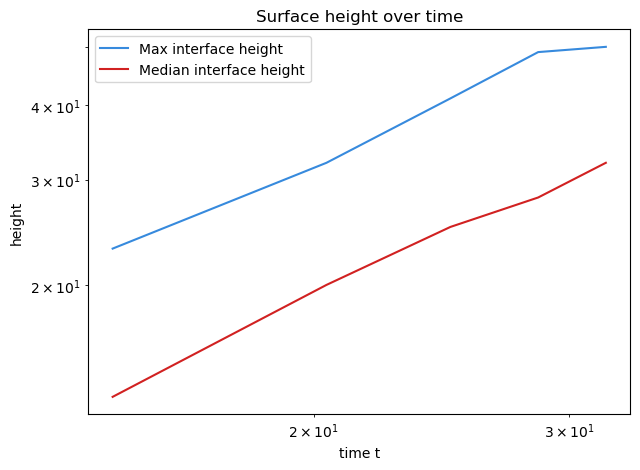

In [47]:
# ============================================================
# plot surface heights over time
# ============================================================
t = obs['t']
max_height = obs['max_height_history']
median_height = obs['median_height_history']
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.5, label="Max interface height")
ax.plot(t, median_height, color="#d12121", lw=1.5, label="Median interface height")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
print(f"Median interface power: {fit_loglog_slope(t, median_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

"""Comments:
Square root scaling of height interface. So to double the height need 
roughly 4x the running time. Also is this what we expect? 
"""

To do list:

- Extract the roughness exponent. The function $w(l, t)$ is supposed to saturate given enough time at $w^*(L)$. In this saturation regime, $w^*(L) \sim L^{\beta}$ where $\beta$ is the roughness exponent.
- Extract the dynamical exponent. For fixed $l = l_0$, the width will increase (prior to saturating) as $w(l_0, t) \sim t^{\alpha}$ where $\alpha$ is the growth exponent. Then scaling arguements say that the dynamical exponent is given as $z=\alpha/\beta$.

Mean log-log slope: 0.4027801914963495


"Comments:\nI don't think that these show signs of saturation. Why are these all so similar?\nMaybe the sliding window average is smoothing it out?\n"

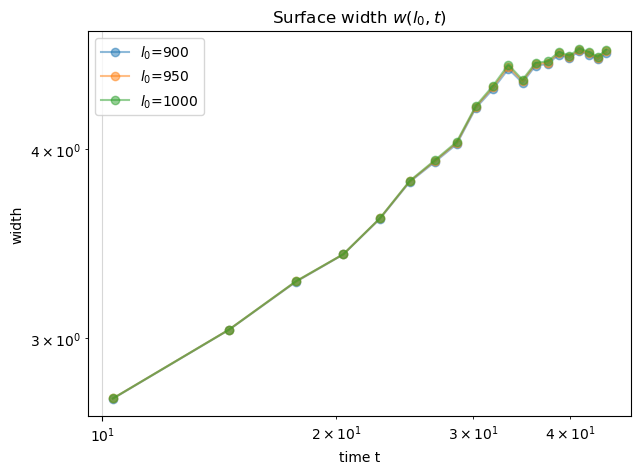

In [52]:
# plot w(l_0, t) as a function of time
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_min = 900 # this is from simulation code
l_0s = [i for i in range(0, l_dim, 50)]
t = obs['t']
fig, ax = plt.subplots(figsize=(7, 5))
for l_0 in l_0s:
    w_l_0 = obs['surface_width_history'][:, l_0]
    log_log_slopes.append(fit_loglog_slope(t, w_l_0))
    ax.plot(t, w_l_0, lw=1.5, label=f"$l_0$={l_0+l_min}", alpha=0.5, marker='o')
ax.set_xlabel("time t")
ax.set_ylabel("width")
ax.set_title("Surface width $w(l_0, t)$")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

"""Comments:
I don't think that these show signs of saturation. Why are these all so similar?
Maybe the sliding window average is smoothing it out?
"""

## Notes

The median interface height scales as $h(t) \sim \sqrt{t}$ where $t$ is the number of steps or attempts. In group meeting, it was mentioned that time slows down as you fill up your lattice. Your chances of a successsful jump basically scales inversely proportional to the remaining number of lattice sites. (Maybe I can do a rough calculation of what this is like. I also need to read the SI from Hallatschek's paper to see how he implemented the algorithm.) 

I need to check the code again for computing this "surface roughness"  

Additionally I need to make sure that my "rate" at which I'm populating the lattice sites stays constant, which is achieved by: 
1) Modifying the code to sample from ANY site on the L by L lattice 
2) Modifying the time step to be inversely proportional to the number of occupied sites. 

When modified by the wall time, we should expect this front to grow linearly in time.